<a href="https://colab.research.google.com/github/jutiyakhun/Graph-Models/blob/main/G1_Graph_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Session1: This session designed for Graph Visualization Workshop**

In [ ]:
# Install and Import Required Libraries
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re

Download dataset and return path

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wcukierski/enron-email-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'enron-email-dataset' dataset.
Path to dataset files: /kaggle/input/enron-email-dataset


Explore the structure of the dataset

In [ ]:
print(os.listdir(path))

['emails.csv']


Download dataset

In [ ]:
csv_path = os.path.join(path, "emails.csv")

df = pd.read_csv(csv_path)

print(df.shape)
df.head()

(517401, 2)


,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [ ]:
df = df.head(1000); df

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...
...,...,...
995,allen-p/all_documents/458.,Message-ID: <20430828.1075855696096.JavaMail.e...
996,allen-p/all_documents/459.,Message-ID: <18425275.1075855696118.JavaMail.e...
997,allen-p/all_documents/46.,Message-ID: <24036204.1075855666506.JavaMail.e...
998,allen-p/all_documents/460.,Message-ID: <33307764.1075855696139.JavaMail.e...


Read an email

In [ ]:
print(df['message'][1])

Message-ID: <15464986.1075855378456.JavaMail.evans@thyme>
Date: Fri, 4 May 2001 13:51:00 -0700 (PDT)
From: phillip.allen@enron.com
To: john.lavorato@enron.com
Subject: Re:
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: John J Lavorato <John J Lavorato/ENRON@enronXgate@ENRON>
X-cc: 
X-bcc: 
X-Folder: \Phillip_Allen_Jan2002_1\Allen, Phillip K.\'Sent Mail
X-Origin: Allen-P
X-FileName: pallen (Non-Privileged).pst

Traveling to have a business meeting takes the fun out of the trip.  Especially if you have to prepare a presentation.  I would suggest holding the business plan meetings here then take a trip without any formal business meetings.  I would even try and get some honest opinions on whether a trip is even desired or necessary.

As far as the business meetings, I think it would be more productive to try and stimulate discussions across the different groups about what is working and what is not.  Too often the

Extract sender, and recipient from text emails

In [ ]:
def extract_field(text, field):
    match = re.search(rf'{field}:\s*(.*)', text) # find 'field'-> skip all spaces-> capture every text that follows.
    return match.group(1).strip() if match else None

df['From'] = df['message'].apply(lambda x: extract_field(x, 'From'))
df['To'] = df['message'].apply(lambda x: extract_field(x, 'To'))

Construct Graph

In [ ]:
G = nx.DiGraph()

for _, row in df.iterrows():
    sender = row['From']
    # Split the 'To' field by comma and strip whitespace from each recipient
    if pd.notna(row['To']):
        recipients = [r.strip() for r in row['To'].split(',')]
    else:
        recipients = []

    if pd.notna(sender):
        for receiver in recipients:
            if receiver: # Ensure receiver is not an empty string
                G.add_edge(sender, receiver)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 246
Number of edges: 246


Create Visualization

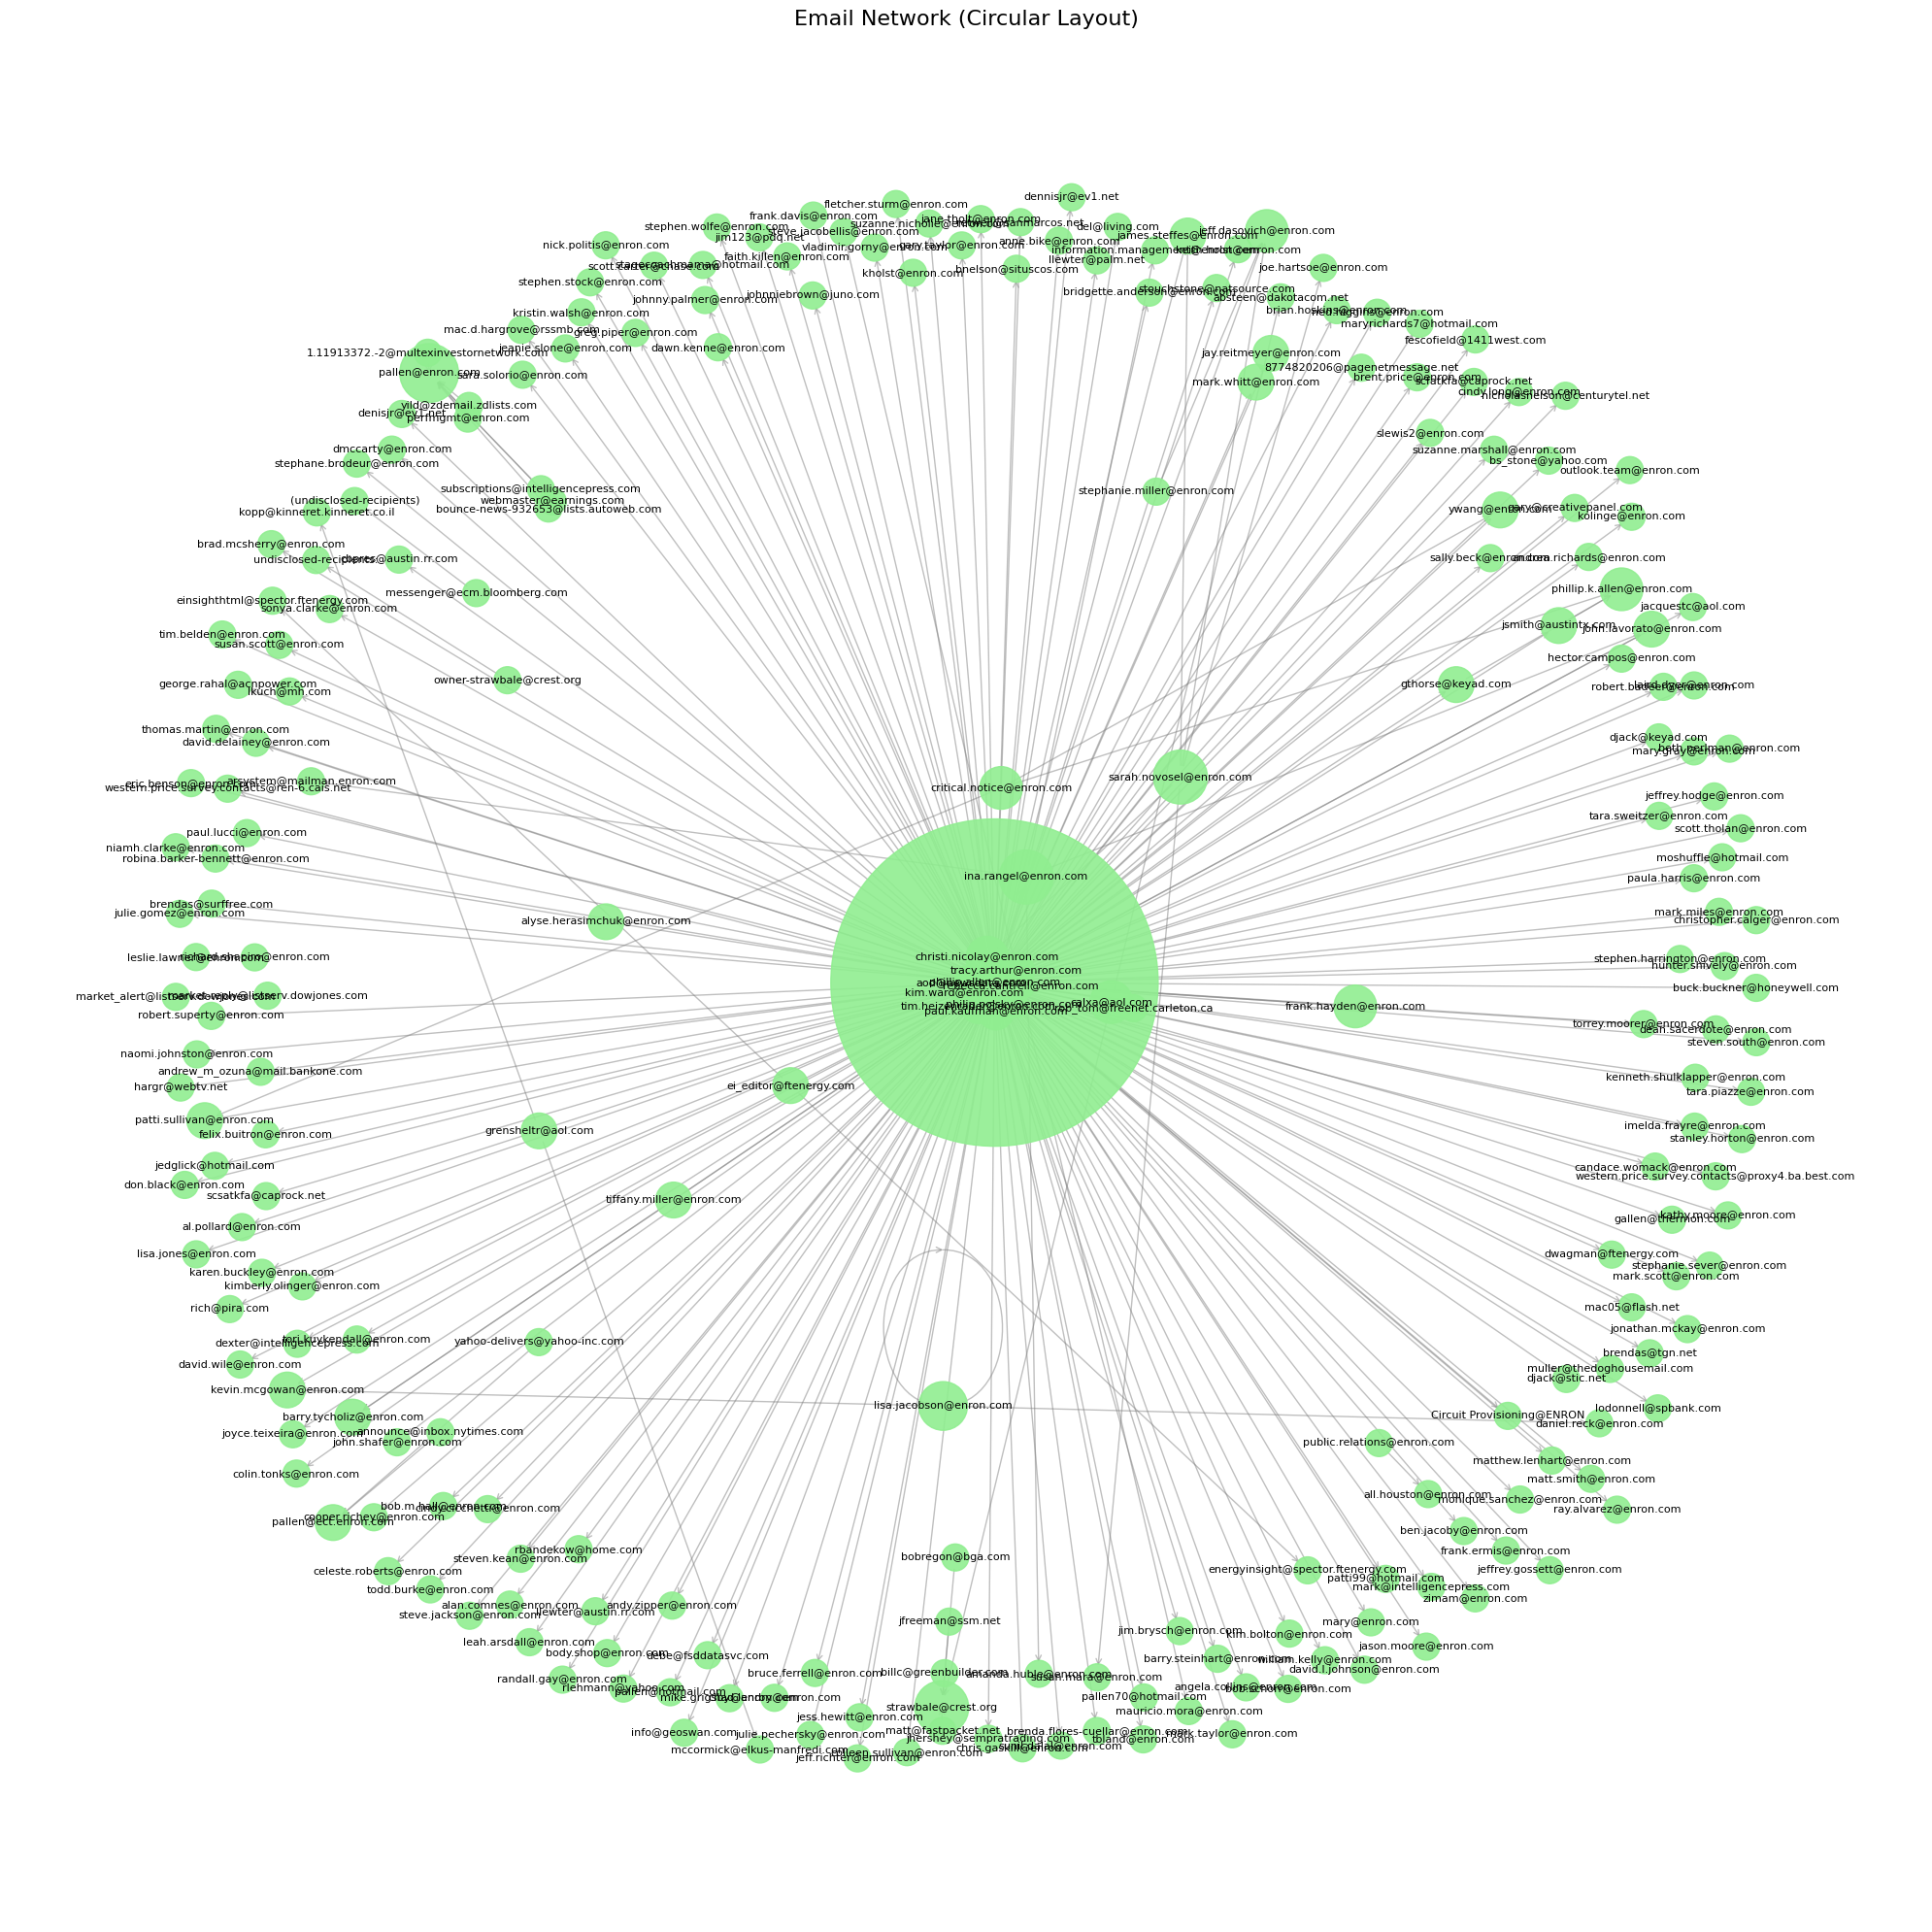

In [ ]:
plt.figure(figsize=(20, 20))

# Plot: Email Network with Circular Layout
pos_circular = nx.spring_layout(G)

# Recalculate node degrees and sizes based on the current G graph
node_degree = dict(G.degree())
node_sizes = [v * 300 + 100 for v in node_degree.values()]

# Draw nodes
nx.draw_networkx_nodes(G, pos_circular, node_color='lightgreen', node_size=node_sizes, alpha=0.9)
# Draw edges with transparency and arrows
nx.draw_networkx_edges(G, pos_circular, edge_color='gray', alpha=0.5, arrowstyle='->', arrowsize=10)
# Draw labels
nx.draw_networkx_labels(G, pos_circular, font_size=8, font_color='black')

plt.title("Email Network (Circular Layout)", size=16)
plt.axis('off') # Hide axes for cleaner look

plt.tight_layout()
plt.show()